In [42]:
# Импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import re
import json
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn import tree
from scipy.stats import randint

In [2]:
# отключаем экспоненциальное отображение чисел в pandas и numpy и делаем удобное форматирование
def smart_float(x):
    if pd.isnull(x):
        return ""
    elif float(x).is_integer():
        return '{:.0f}'.format(x) # отображаем целые числа без нулевой десятичной части
    else:
        return '{:.6f}'.format(x).rstrip('0').rstrip('.') # отображаем числа с плавающей запятой без лишних нулей

pd.set_option('display.float_format', smart_float)
np.set_printoptions(suppress=True)
# Снимаем ограничение на число отображаемых столбцов в pandas
pd.set_option('display.max_columns', None)      # показывать все столбцы
pd.set_option('display.width', None)            # не ограничивать ширину вывода
pd.set_option('display.max_colwidth', None)     # не ограничивать ширину столбца

In [3]:
# Загружаем результаты из прошлого этапа, будем добавлять новые для сравнения
with open('results.json', 'r', encoding='utf-8') as f:
    results = json.load(f)

In [4]:
# Функция для добавления результатов модели в общий список и отображения итоговой таблицы
def add_result_prob(name, y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "Model": name,
        "PR-AUC": average_precision_score(y_true, y_prob),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    })
    
def show_results():

    df = pd.DataFrame(results)

    df = df.sort_values("PR-AUC", ascending=False)

    display(df.round(4))

In [ ]:
# Функция для оценки модели на разных порогах и сохранения лучших результатов
def evaluate_model_thresholds(
    model=None, 
    X_validate=None, 
    y_validate=None, 
    X_test=None, 
    y_test=None
):
    if model is None:
        model = globals().get('model')
    if X_validate is None:
        X_validate = globals().get('X_validate')
    if y_validate is None:
        y_validate = globals().get('y_validate')
    if X_test is None:
        X_test = globals().get('X_test')
    if y_test is None:
        y_test = globals().get('y_test')

    val_proba = model.predict_proba(X_validate)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    val_pr_auc = average_precision_score(y_validate, val_proba)
    test_pr_auc = average_precision_score(y_test, test_proba)

    val_roc_auc = roc_auc_score(y_validate, val_proba)
    test_roc_auc = roc_auc_score(y_test, test_proba)

    print("=== Метрики ===")
    print(f"VALIDATE PR-AUC: {val_pr_auc:.6f}")
    print(f"TEST     PR-AUC: {test_pr_auc:.6f}")
    print(f"VALIDATE ROC-AUC: {val_roc_auc:.6f}")
    print(f"TEST     ROC-AUC: {test_roc_auc:.6f}")

    thresholds = np.linspace(0.01, 0.99, 100)
    rows = []

    for t in thresholds:
        val_pred = (val_proba >= t).astype(int)
        precision = precision_score(y_validate, val_pred, zero_division=0)
        recall = recall_score(y_validate, val_pred, zero_division=0)
        f1 = f1_score(y_validate, val_pred, zero_division=0)
        rows.append({
            'threshold': t,
            'precision': precision,
            'recall': recall,
            'f1': f1
        })

    threshold_df = pd.DataFrame(rows)

    best_f1_row = threshold_df.loc[threshold_df['f1'].idxmax()]
    best_precision_row = threshold_df.loc[threshold_df['precision'].idxmax()]
    best_recall_row = threshold_df.loc[threshold_df['recall'].idxmax()]

    print("\n=== ЛУЧШИЕ ПОРОГИ (VALIDATE) ===")
    print("\nЛучший F1:")
    print(best_f1_row)
    print("\nЛучший Precision:")
    print(best_precision_row)
    print("\nЛучший Recall:")
    print(best_recall_row)

    best_threshold = best_f1_row['threshold']
    test_pred = (test_proba >= best_threshold).astype(int)
    test_precision = precision_score(y_test, test_pred, zero_division=0)
    test_recall = recall_score(y_test, test_pred, zero_division=0)
    test_f1 = f1_score(y_test, test_pred, zero_division=0)

    print("\n=== ТОП-10 ПОРОГОВ ПО F1 (VALIDATE) ===")
    display(threshold_df.sort_values('f1', ascending=False).head(10))

    print("\n=== ФИНАЛЬНЫЕ МЕТРИКИ TEST (лучший порог по F1) ===")
    print(f"Порог: {best_threshold:.4f}")
    print(f"Precision: {test_precision:.6f}")
    print(f"Recall:    {test_recall:.6f}")
    print(f"F1:        {test_f1:.6f}")

    return best_threshold

## 5.1 Базовая модель на базе решающего дерева

In [ ]:
# Загружаем данные
data = pd.read_parquet('data_tree.parquet')
with open('data_tree_schema.json', 'r', encoding='utf-8') as f:
    schema = json.load(f)

# сначала datetime
for col in schema['datetime_cols']:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors='coerce')

# потом category
for col in schema['category_cols']:
    if col in data.columns:
        data[col] = data[col].astype('category')

# потом остальные типы
for col, dtype_str in schema['dtypes'].items():
    if col not in data.columns:
        continue
    
    if col in schema['datetime_cols'] or col in schema['category_cols']:
        continue
    
    try:
        if dtype_str == 'object':
            data[col] = data[col].astype('string')
        else:
            data[col] = data[col].astype(dtype_str)
    except Exception as e:
        print(f'Не удалось привести {col} к {dtype_str}: {e}')
        
# Делаем MCC категориальным признаком
data['MCC'] = data['MCC'].astype('category')

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7890638 entries, 0 to 7890637
Data columns (total 55 columns):
 #   Column                               Dtype   
---  ------                               -----   
 0   Amount                               float32 
 1   Use_Chip                             int8    
 2   Is_Online                            int8    
 3   Merchant_State                       category
 4   MCC                                  category
 5   Has_Error                            int8    
 6   Fraud                                int8    
 7   Gender                               int8    
 8   Is_Apartment                         int8    
 9   Total_Debt                           float32 
 10  FICO                                 int16   
 11  Num_Credit_Cards                     int8    
 12  Card_Brand                           category
 13  Card_Type                            category
 14  Has_Chip                             int8    
 15  Cards_Issued   

In [7]:
data.head() 

,Amount,Use_Chip,Is_Online,Merchant_State,MCC,Has_Error,Fraud,Gender,Is_Apartment,Total_Debt,FICO,Num_Credit_Cards,Card_Brand,Card_Type,Has_Chip,Cards_Issued,Credit_Limit,txn_hour,txn_dayofweek,txn_day,is_weekend,account_age_months,Amount_to_Income,Error_Bad_CVV,Error_Bad_Card_Number,Error_Bad_Expiration,Error_Bad_PIN,Error_Bad_Zipcode,Error_Insufficient_Balance,Error_Technical_Glitch,user_age,is_night,is_business_hours,amount_log,amount_round_10,time_since_prev_txn_card_min,time_since_prev_txn_user_min,txn_gap_bin,first_user_payment_to_this_merchant,txn_count_5m_card,txn_count_1h_card,txn_count_5m_user,txn_count_1h_user,state_changed_1d,errors_prev_1h,merchant_txn_count_24h,merchant_amount_sum_24h,merchant_txn_count_1h,merchant_amount_sum_1h,merchant_velocity_ratio_log,card_burst_5m,merchant_fraud_rate,state_fraud_rate,prev_not_foreign_card,is_foreign_offline
0,69.550003,1,0,TX,5411,0,0,1,0,73726,719,4,Visa,Credit,1,2,10500,0,3,1,0,156,0.020933,0,0,0,0,0,0,0,31,1,0,4.256322,0,1231,1231,6,0,1,1,1,1,0,0,179,6272.97998,9,346.649994,-2.890372,0,0,0.000191,1,0
1,34.82,0,0,FL,5814,0,0,0,1,0,688,3,Visa,Debit,0,1,14708,0,3,1,0,12,0.009895,0,0,0,0,0,0,0,30,1,0,3.578506,0,587,587,6,0,1,1,1,1,0,0,175,6165.709961,7,292.970001,-3.091043,0,0.000031,0.000286,1,0
2,64.400002,1,0,MD,5813,0,0,1,0,96182,711,2,Visa,Debit,1,1,19113,0,3,1,0,67,0.011305,0,0,0,0,0,0,0,46,1,0,4.180522,0,1442,1442,7,0,1,1,1,1,0,0,176,6188.689941,5,186.819992,-3.38439,0,0,0.000316,1,0
3,47.93,1,0,CA,4121,0,0,1,0,15336,743,5,Mastercard,Debit,1,1,16279,0,3,1,0,36,0.018576,0,0,0,0,0,0,0,62,1,0,3.890391,0,74,74,5,0,1,1,1,1,1,0,177,6219.02002,6,217.149994,-3.235873,0,0,0.000378,0,0
4,25.75,0,1,NaN,5311,0,0,0,1,109558,707,3,Visa,Debit,0,1,12370,0,3,1,0,130,0.006398,0,0,0,0,0,0,0,44,1,0,3.286535,0,355,355,6,0,1,1,1,1,1,0,178,6262.739746,7,260.869995,-3.107944,0,0.002364,0,0,0


In [8]:
# Разбиваем на train, validate и test по времени в пропорции 70/15/15
train, test = train_test_split(data, test_size=0.3, shuffle=False)
validate, test = train_test_split(test, test_size=0.5, shuffle=False)
X_train, y_train = train.drop(columns=['Fraud']), train['Fraud']
X_validate, y_validate = validate.drop(columns=['Fraud']), validate['Fraud']
X_test, y_test = test.drop(columns=['Fraud']), test['Fraud']

In [9]:
# Кодируем категориальные признаки для моделей на деревьях
cat_cols = X_train.select_dtypes(include=['category', 'object']).columns.tolist()

ord_encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
X_train[cat_cols] = ord_encoder.fit_transform(X_train[cat_cols])
X_validate[cat_cols] = ord_encoder.transform(X_validate[cat_cols])
X_test[cat_cols] = ord_encoder.transform(X_test[cat_cols])

In [10]:
# Обучаем простое дерево без подбора гиперпараметров и без балансировки классов, просто чтобы посмотреть на результат.
model_simple_tree = DecisionTreeClassifier(random_state=42)

model_simple_tree.fit(X_train, y_train)

y_pred_simple_tree = model_simple_tree.predict(X_validate)
y_prob_simple_tree = model_simple_tree.predict_proba(X_validate)[:,1]

print("Простое дерево решений:")
print(confusion_matrix(y_validate, y_pred_simple_tree))

Простое дерево решений:
[[1174784    7067]
 [    625    1120]]


In [11]:
print(classification_report(y_validate, y_pred_simple_tree))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1181851
           1       0.14      0.64      0.23      1745

    accuracy                           0.99   1183596
   macro avg       0.57      0.82      0.61   1183596
weighted avg       1.00      0.99      1.00   1183596



In [12]:
best_threshold = evaluate_model_thresholds(model_simple_tree, X_validate, y_validate, X_test, y_test)

=== Метрики ===
VALIDATE PR-AUC: 0.088332
TEST     PR-AUC: 0.049891
VALIDATE ROC-AUC: 0.817927
TEST     ROC-AUC: 0.775375

=== ЛУЧШИЕ ПОРОГИ (VALIDATE) ===

Лучший F1:
threshold       0.01
precision   0.136802
recall      0.641834
f1          0.225534
Name: 0, dtype: float64

Лучший Precision:
threshold       0.01
precision   0.136802
recall      0.641834
f1          0.225534
Name: 0, dtype: float64

Лучший Recall:
threshold       0.01
precision   0.136802
recall      0.641834
f1          0.225534
Name: 0, dtype: float64

=== ТОП-10 ПОРОГОВ ПО F1 (VALIDATE) ===


,threshold,precision,recall,f1
0,0.01,0.136802,0.641834,0.225534
1,0.019899,0.136802,0.641834,0.225534
2,0.029798,0.136802,0.641834,0.225534
3,0.039697,0.136802,0.641834,0.225534
4,0.049596,0.136802,0.641834,0.225534
5,0.059495,0.136802,0.641834,0.225534
6,0.069394,0.136802,0.641834,0.225534
7,0.079293,0.136802,0.641834,0.225534
8,0.089192,0.136802,0.641834,0.225534
9,0.099091,0.136802,0.641834,0.225534



=== ФИНАЛЬНЫЕ МЕТРИКИ TEST (лучший порог по F1) ===
Порог: 0.0100
Precision: 0.087977
Recall:    0.559530
F1:        0.152047


In [13]:
y_pred_simple_tree = model_simple_tree.predict(X_test)
y_prob_simple_tree = model_simple_tree.predict_proba(X_test)[:,1]
add_result_prob("Простое дерево решений (без ограничений по размеру, тест)", y_test, y_prob_simple_tree, threshold=best_threshold)
show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
11,"Логистическая регрессия (без подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5957,0.9963,0.9989,0.7781,0.398,0.5266
9,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.5957,0.9963,0.9989,0.7781,0.398,0.5266
12,"Логистическая регрессия (после подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5813,0.9958,0.9987,0.5781,0.5254,0.5505
10,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.5813,0.9958,0.9988,0.6226,0.4925,0.5499
13,Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации,0.5391,0.9906,0.9987,0.5934,0.4716,0.5255
14,Логистическая регрессия (с PCA + OHE) на валидации,0.4918,0.9977,0.9946,0.2026,0.8991,0.3306
6,Простая логистическая регрессия (без MCC) на валидации,0.3955,0.9788,0.9988,0.781,0.2453,0.3733
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.3918,0.9865,0.9987,0.7171,0.247,0.3674
7,Логистическая регрессия (с подобранными гиперпараметрами) на валидации,0.3848,0.9862,0.9985,0.5091,0.3513,0.4157
8,Логистическая регрессия (с подобранными гиперпараметрами) на тесте,0.3823,0.9844,0.9985,0.5222,0.3549,0.4226


Дерево показала результаты хуже скоринга на основе правил. Посмотрим причины такого результата.

In [14]:
print("Число листьев:", model_simple_tree.get_n_leaves())
print("Число узлов:", model_simple_tree.tree_.node_count)
print("Глубина дерева:", model_simple_tree.get_depth())

Число листьев: 3327
Число узлов: 6653
Глубина дерева: 32


Как видим, модель сильно переобучилась.

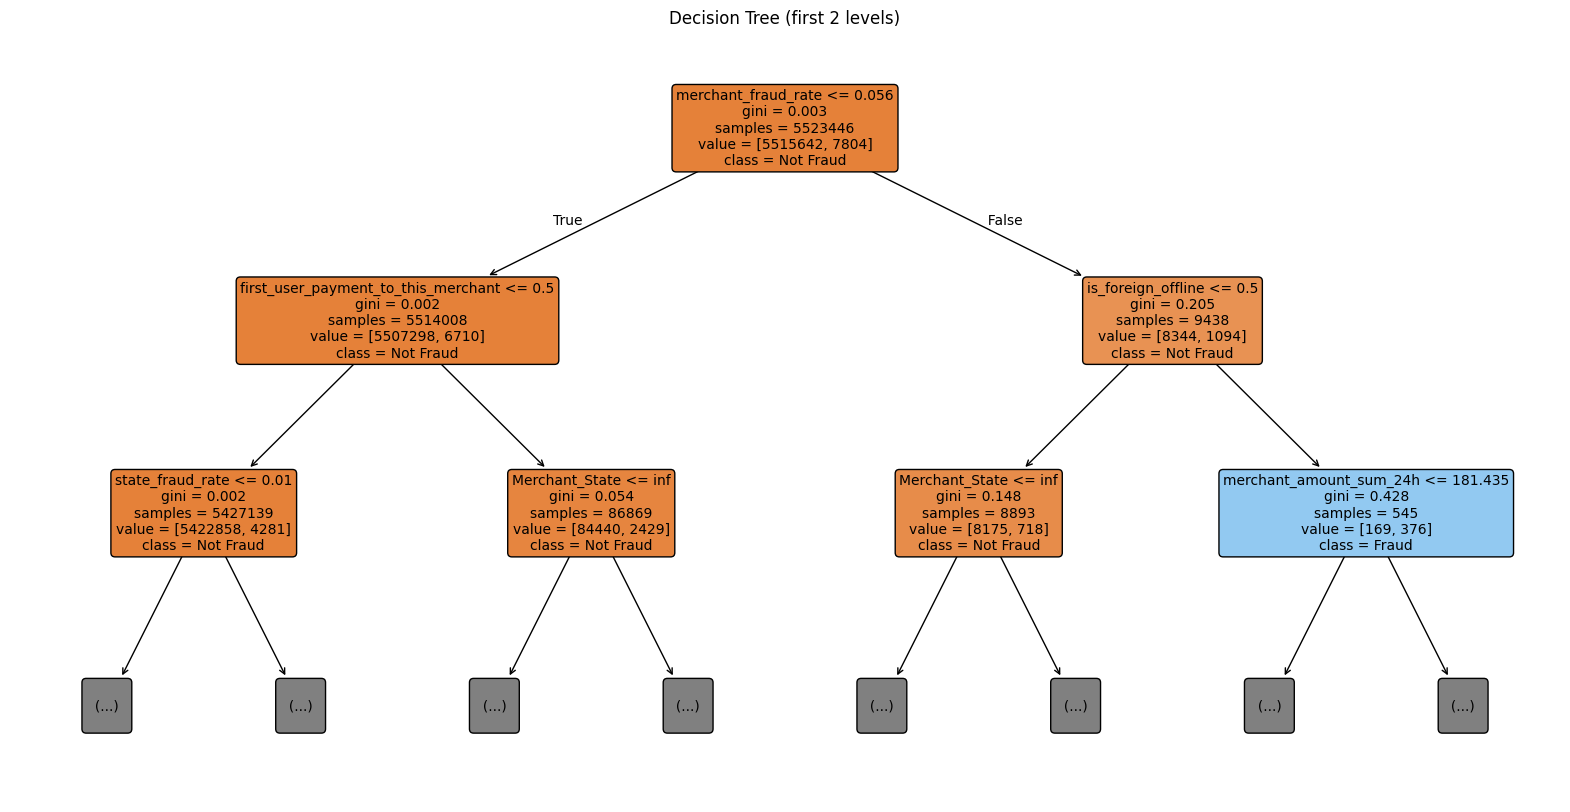

In [15]:

plt.figure(figsize=(20,10))

tree.plot_tree(
    model_simple_tree,
    max_depth=2,                 # показываем только первые 2 уровня
    feature_names=X_train.columns,
    class_names=['Not Fraud','Fraud'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree (first 2 levels)")
plt.show()

Как видим, значимыми критерями модель определила фактор первой оплаты пользователя у конкретного продваца, иностранные офф-лайн транзакции, уровень мошенничества в стране и саму страну. Кроме того, одним из критерем оказалась сумма транзакций у мерчанта. Пока не можем сказать, насколько такое разделение оптимально.

Как о ожидалось - если не ограничивать "размеры" дерева оно "разростается" и "переобучается", что приводит к низким показателям. На данный момент дерево показала намного лучший показатель по числу "отловленного" мошенничества, чем линейная модель, но сгенерировала неприемлимое колличество ложноположительных результатов.
Попробуем подобрать оптимальные параметры одного дерева.

Как видим, качество деревьев решений оказалось существенно ниже, чем у логистической регрессии. Попробуем Grid Search

In [16]:
# Подберем параметры одного дерева решений с помощью GridSearchCV и TimeSeriesSplit
if True:
    tscv = TimeSeriesSplit(n_splits=3) # Данных очень много, использууем 3 фолда для ускорения обучения.
    grid_single_tree = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_grid = {
            'criterion': ['gini', 'entropy'],
            'max_depth': [10, 20, 30],
            'min_samples_split': [20, 50, 200],
            'min_samples_leaf': [10, 50, 200],
            'class_weight': [None, 'balanced'],
            'max_features': [None, 'sqrt', 'log2']
            },
        scoring='average_precision', 
        cv=tscv,
        n_jobs=8,
        verbose=10
    )

    grid_single_tree.fit(X_train, y_train)

    print("Лучшие параметры:")
    print(grid_single_tree.best_params_)

    print("\nЛучший средний PR-AUC на CV:")
    print(grid_single_tree.best_score_)

    # Лучшая уже обученная модель
    best_single_tree = grid_single_tree.best_estimator_

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Лучшие параметры:
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 200}

Лучший средний PR-AUC на CV:
0.2674179550996311


Fitting 3 folds for each of 324 candidates, totalling 972 fits
Лучшие параметры:
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 200}

Лучший средний PR-AUC на CV:
0.2674179550996311

In [17]:
best_threshold = evaluate_model_thresholds(best_single_tree, X_validate, y_validate, X_test, y_test)

=== Метрики ===
VALIDATE PR-AUC: 0.554359
TEST     PR-AUC: 0.498150
VALIDATE ROC-AUC: 0.951847
TEST     ROC-AUC: 0.949235

=== ЛУЧШИЕ ПОРОГИ (VALIDATE) ===

Лучший F1:
threshold       0.99
precision   0.406313
recall      0.811461
f1          0.541491
Name: 99, dtype: float64

Лучший Precision:
threshold       0.99
precision   0.406313
recall      0.811461
f1          0.541491
Name: 99, dtype: float64

Лучший Recall:
threshold       0.01
precision   0.107793
recall      0.906017
f1          0.192664
Name: 0, dtype: float64

=== ТОП-10 ПОРОГОВ ПО F1 (VALIDATE) ===


,threshold,precision,recall,f1
99,0.99,0.406313,0.811461,0.541491
98,0.980101,0.321466,0.879656,0.470859
97,0.970202,0.224546,0.88596,0.358285
96,0.960303,0.199512,0.891117,0.32603
95,0.950404,0.184313,0.892837,0.30555
94,0.940505,0.16831,0.899713,0.283573
93,0.930606,0.152694,0.899713,0.261079
92,0.920707,0.144181,0.90086,0.248577
91,0.910808,0.136529,0.902579,0.237181
90,0.900909,0.131428,0.903725,0.229482



=== ФИНАЛЬНЫЕ МЕТРИКИ TEST (лучший порог по F1) ===
Порог: 0.9900
Precision: 0.401164
Recall:    0.808832
F1:        0.536323


In [18]:
add_result_prob("Дерево решений (с GridSearchCV, тест)", y_test, best_single_tree.predict_proba(X_test)[:,1], threshold=best_threshold) 
show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
11,"Логистическая регрессия (без подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5957,0.9963,0.9989,0.7781,0.398,0.5266
9,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.5957,0.9963,0.9989,0.7781,0.398,0.5266
12,"Логистическая регрессия (после подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5813,0.9958,0.9987,0.5781,0.5254,0.5505
10,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.5813,0.9958,0.9988,0.6226,0.4925,0.5499
13,Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации,0.5391,0.9906,0.9987,0.5934,0.4716,0.5255
16,"Дерево решений (с GridSearchCV, тест)",0.4981,0.9492,0.9979,0.4012,0.8088,0.5363
14,Логистическая регрессия (с PCA + OHE) на валидации,0.4918,0.9977,0.9946,0.2026,0.8991,0.3306
6,Простая логистическая регрессия (без MCC) на валидации,0.3955,0.9788,0.9988,0.781,0.2453,0.3733
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.3918,0.9865,0.9987,0.7171,0.247,0.3674
7,Логистическая регрессия (с подобранными гиперпараметрами) на валидации,0.3848,0.9862,0.9985,0.5091,0.3513,0.4157


Дерево решений демонстрирует поведение агрессивной антифрод-модели с высоким покрытием, способной выявлять около 81% мошеннических операций, что существенно снижает прямые финансовые потери от пропущенного fraud, однако при этом точность остаётся на уровне ~40%, то есть более половины срабатываний являются ложными и требуют дополнительной проверки: большинство алертов окажутся ложными, создавая серьёзную нагрузку на операционные команды и потенциальное раздражение клиентов при блокировка. Модель не подходит для автоматических блокировок и должна использоваться как первый уровень фильтрации (широкий детектор) с последующей передачей операций на ручную проверку или как часть стекинга (например, вместе с логистической регрессией).

## 5.2 Ансамблевые модели

In [19]:
best_single_tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 20,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 10,
 'min_samples_split': 200,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [24]:
# Базовый Random Forest — параметры возьмём на основе предыдущего опыта построения одиночного дерева.

rf_basic = RandomForestClassifier(
    n_estimators=500,
    criterion='entropy',
    max_depth=20,
    min_samples_leaf=10,
    min_samples_split=200,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=8,
    random_state=42
)

rf_basic.fit(X_train, y_train)

y_prob_rf_basic = rf_basic.predict_proba(X_validate)[:, 1]




In [23]:
best_threshold = evaluate_model_thresholds(rf_basic, X_validate, y_validate, X_test, y_test)

=== Метрики ===
VALIDATE PR-AUC: 0.787419
TEST     PR-AUC: 0.718026
VALIDATE ROC-AUC: 0.999291
TEST     ROC-AUC: 0.999244

=== ЛУЧШИЕ ПОРОГИ (VALIDATE) ===

Лучший F1:
threshold   0.851414
precision   0.729794
recall      0.708883
f1          0.719186
Name: 85, dtype: float64

Лучший Precision:
threshold   0.980101
precision   0.955556
recall      0.123209
f1          0.218274
Name: 98, dtype: float64

Лучший Recall:
threshold       0.01
precision   0.012405
recall             1
f1          0.024506
Name: 0, dtype: float64

=== ТОП-10 ПОРОГОВ ПО F1 (VALIDATE) ===


,threshold,precision,recall,f1
85,0.851414,0.729794,0.708883,0.719186
84,0.841515,0.708797,0.729513,0.719006
86,0.861313,0.754408,0.686533,0.718872
83,0.831616,0.686779,0.750143,0.717064
87,0.871212,0.776725,0.65788,0.71238
82,0.821717,0.662866,0.766189,0.710792
81,0.811818,0.644235,0.784527,0.707494
88,0.881111,0.800146,0.626361,0.702668
80,0.801919,0.625394,0.795989,0.700454
79,0.79202,0.61135,0.8149,0.6986



=== ФИНАЛЬНЫЕ МЕТРИКИ TEST (лучший порог по F1) ===
Порог: 0.8514
Precision: 0.678616
Recall:    0.613751
F1:        0.644555


In [37]:
# Результат на тесте
add_result_prob("Базовый RF 500 деревьев (Test)", y_test, rf_basic.predict_proba(X_test)[:,1], threshold=best_threshold)

show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
17,Базовый RF 500 деревьев (Test),0.718,0.9992,0.999,0.6786,0.6138,0.6446
9,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.5957,0.9963,0.9989,0.7781,0.398,0.5266
11,"Логистическая регрессия (без подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5957,0.9963,0.9989,0.7781,0.398,0.5266
12,"Логистическая регрессия (после подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5813,0.9958,0.9987,0.5781,0.5254,0.5505
10,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.5813,0.9958,0.9988,0.6226,0.4925,0.5499
13,Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации,0.5391,0.9906,0.9987,0.5934,0.4716,0.5255
16,"Дерево решений (с GridSearchCV, тест)",0.4981,0.9492,0.9979,0.4012,0.8088,0.5363
14,Логистическая регрессия (с PCA + OHE) на валидации,0.4918,0.9977,0.9946,0.2026,0.8991,0.3306
6,Простая логистическая регрессия (без MCC) на валидации,0.3955,0.9788,0.9988,0.781,0.2453,0.3733
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.3918,0.9865,0.9987,0.7171,0.247,0.3674


Лес показал отличный результат уже на самых базовых параметрах. 

In [43]:
# Попробуем подобрать параметры для Random Forest с помощью RandomizedSearchCV, так как полный GridSearch будет слишком долгим.
tscv = TimeSeriesSplit(n_splits=3)

rf = RandomForestClassifier(
    n_estimators=200, # Для ускорения обучения берем мало деревьев
    class_weight='balanced',
    n_jobs=8,
    random_state=42
)

param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': randint(5, 30),
    'min_samples_split': randint(10, 300),
    'max_features': ['sqrt', 'log2', 0.2, 0.3, 0.5]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=12,
    scoring='average_precision',
    cv=tscv,
    verbose=10,
    n_jobs=8,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Лучшие параметры:")
print(random_search.best_params_)
print("Лучший PR-AUC (CV):", random_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Лучшие параметры:
{'criterion': 'entropy', 'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 16, 'min_samples_split': 58}
Лучший PR-AUC (CV): 0.4935123811545216


In [44]:
best_threshold = evaluate_model_thresholds(random_search, X_validate, y_validate, X_test, y_test)

=== Метрики ===
VALIDATE PR-AUC: 0.837841
TEST     PR-AUC: 0.760898
VALIDATE ROC-AUC: 0.999181
TEST     ROC-AUC: 0.999172

=== ЛУЧШИЕ ПОРОГИ (VALIDATE) ===

Лучший F1:
threshold   0.871212
precision   0.792256
recall      0.738682
f1          0.764531
Name: 87, dtype: float64

Лучший Precision:
threshold       0.99
precision   0.961151
recall      0.382808
f1          0.547541
Name: 99, dtype: float64

Лучший Recall:
threshold       0.01
precision   0.026571
recall             1
f1          0.051766
Name: 0, dtype: float64

=== ТОП-10 ПОРОГОВ ПО F1 (VALIDATE) ===


,threshold,precision,recall,f1
87,0.871212,0.792256,0.738682,0.764531
86,0.861313,0.778042,0.751289,0.764431
90,0.900909,0.837432,0.702579,0.764101
88,0.881111,0.803424,0.726074,0.762793
89,0.89101,0.817705,0.714613,0.762691
85,0.851414,0.762206,0.760458,0.761331
91,0.910808,0.847242,0.686533,0.758468
84,0.841515,0.745706,0.771347,0.75831
83,0.831616,0.730975,0.781662,0.755469
92,0.920707,0.860602,0.672206,0.754826



=== ФИНАЛЬНЫЕ МЕТРИКИ TEST (лучший порог по F1) ===
Порог: 0.8712
Precision: 0.722120
Recall:    0.655115
F1:        0.686987


In [45]:
add_result_prob("Случайный лес (с подобраными гипер-параметрами, test)", y_test, random_search.predict_proba(X_test)[:,1], threshold=best_threshold)
show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
18,"Случайный лес (с подобраными гипер-параметрами, test)",0.7609,0.9992,0.9991,0.7221,0.6551,0.687
17,Базовый RF 500 деревьев (Test),0.718,0.9992,0.999,0.6786,0.6138,0.6446
9,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.5957,0.9963,0.9989,0.7781,0.398,0.5266
11,"Логистическая регрессия (без подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5957,0.9963,0.9989,0.7781,0.398,0.5266
12,"Логистическая регрессия (после подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5813,0.9958,0.9987,0.5781,0.5254,0.5505
10,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.5813,0.9958,0.9988,0.6226,0.4925,0.5499
13,Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации,0.5391,0.9906,0.9987,0.5934,0.4716,0.5255
16,"Дерево решений (с GridSearchCV, тест)",0.4981,0.9492,0.9979,0.4012,0.8088,0.5363
14,Логистическая регрессия (с PCA + OHE) на валидации,0.4918,0.9977,0.9946,0.2026,0.8991,0.3306
6,Простая логистическая регрессия (без MCC) на валидации,0.3955,0.9788,0.9988,0.781,0.2453,0.3733


Случайный лес с подобранными параметрами демонстрирует сбалансированную и практически применимую в продакшене модель антифрода: при рабочем пороге он выявляет около 65% всех мошеннических операций (recall), одновременно сохраняя высокую точность ~72% (precision), что означает, что большинство срабатываний действительно являются мошенничеством и не создают избыточной нагрузки на операционные команды; такое сочетание метрик позволяет использовать модель не только как инструмент для генерации алертов, но и как основу для автоматической блокировки высокорисковых транзакций, особенно при дополнительной настройке порогов под бизнес-риски, обеспечивая эффективный баланс между снижением финансовых потерь и контролем ложных срабатываний.

In [46]:
import optuna

# ----------------------------
# 1. НАСТРОЙКИ
# ----------------------------
N_SPLITS = 3
N_TRIALS = 40         
RANDOM_STATE = 42
N_JOBS = 8

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# ----------------------------
# 2. OBJECTIVE FUNCTION
# ----------------------------
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 500, step=50),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'max_depth': trial.suggest_categorical('max_depth', [10, 15, 20, None]),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 20, 200),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.2, 0.3, 0.5]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
        'bootstrap': True,
        'n_jobs': N_JOBS,
        'random_state': RANDOM_STATE,
    }

    cv_scores = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr = X_train.iloc[train_idx] if hasattr(X_train, 'iloc') else X_train[train_idx]
        X_val = X_train.iloc[val_idx] if hasattr(X_train, 'iloc') else X_train[val_idx]

        y_tr = y_train.iloc[train_idx] if hasattr(y_train, 'iloc') else y_train[train_idx]
        y_val = y_train.iloc[val_idx] if hasattr(y_train, 'iloc') else y_train[val_idx]

        model = RandomForestClassifier(**params)
        model.fit(X_tr, y_tr)

        y_prob = model.predict_proba(X_val)[:, 1]
        score = average_precision_score(y_val, y_prob)
        cv_scores.append(score)

    return float(np.mean(cv_scores))

# ----------------------------
# 3. ЗАПУСК OPTUNA
# ----------------------------
study = optuna.create_study(direction='maximize', study_name='rf_timeseries_pr_auc')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Лучший trial:", study.best_trial.number)
print("Лучший PR-AUC (CV):", study.best_value)
print("Лучшие параметры:")
print(study.best_params)

# ----------------------------
# 4. ФИНАЛЬНАЯ МОДЕЛЬ
# ----------------------------
best_params = study.best_params.copy()
best_params.update({
    'bootstrap': True,
    'n_jobs': N_JOBS,
    'random_state': RANDOM_STATE,
})

rf_optuna = RandomForestClassifier(**best_params)
rf_optuna.fit(X_train, y_train)

# Валидация
y_prob_val = rf_optuna.predict_proba(X_validate)[:, 1]
val_pr_auc = average_precision_score(y_validate, y_prob_val)

# Тест
y_prob_test = rf_optuna.predict_proba(X_test)[:, 1]
test_pr_auc = average_precision_score(y_test, y_prob_test)

print("\nPR-AUC на validate:", val_pr_auc)
print("PR-AUC на test:", test_pr_auc)

c:\Users\dmytr\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-20 18:32:10,321] A new study created in memory with name: rf_timeseries_pr_auc
Best trial: 0. Best value: 0.347865:   2%|▎         | 1/40 [19:20<12:34:17, 1160.44s/it]

[I 2026-03-20 18:51:30,758] Trial 0 finished with value: 0.34786542015277006 and parameters: {'n_estimators': 350, 'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 29, 'min_samples_split': 195, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.34786542015277006.


Best trial: 1. Best value: 0.427511:   5%|▌         | 2/40 [46:13<15:03:25, 1426.45s/it]

[I 2026-03-20 19:18:23,418] Trial 1 finished with value: 0.4275110027699951 and parameters: {'n_estimators': 450, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 29, 'min_samples_split': 46, 'max_features': 0.2, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.4275110027699951.


Best trial: 1. Best value: 0.427511:   8%|▊         | 3/40 [1:19:53<17:26:53, 1697.67s/it]

...

[I 2026-03-21 17:11:19,712] Trial 37 finished with value: 0.2795246708711677 and parameters: {'n_estimators': 400, 'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 30, 'min_samples_split': 57, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 22 with value: 0.5052559445405875.


Best trial: 22. Best value: 0.505256:  98%|█████████▊| 39/40 [23:24:29<39:02, 2342.18s/it]  

[I 2026-03-21 17:56:39,328] Trial 38 finished with value: 0.48756270732147283 and parameters: {'n_estimators': 350, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 9, 'min_samples_split': 124, 'max_features': 0.5, 'class_weight': 'balanced'}. Best is trial 22 with value: 0.5052559445405875.


Best trial: 22. Best value: 0.505256: 100%|██████████| 40/40 [23:44:05<00:00, 2136.15s/it]


[I 2026-03-21 18:16:16,229] Trial 39 finished with value: 0.4084524495728195 and parameters: {'n_estimators': 350, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 8, 'min_samples_split': 103, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 22 with value: 0.5052559445405875.
Лучший trial: 22
Лучший PR-AUC (CV): 0.5052559445405875
Лучшие параметры:
{'n_estimators': 250, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 53, 'max_features': 0.5, 'class_weight': 'balanced'}

PR-AUC на validate: 0.8619908845937998
PR-AUC на test: 0.7790698583141467


Optuna смогла подобрать гиперпараметры, которые ещё сильнее улучшили качество модели. Однако, смущает то, что показатель PR-AUC сильно ниже, чем итоговые показатели на валидации и тесте. Необходимо провести дополнительную проверку, не является ли результат аномалией. 

In [55]:
print("train fraud rate:", y_train.mean())
print("validate fraud rate:", y_validate.mean())
print("test fraud rate:", y_test.mean())

for i, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    y_val_fold = y_train.iloc[val_idx] if hasattr(y_train, 'iloc') else y_train[val_idx]
    print(f"Fold {i}: fraud_rate={y_val_fold.mean():.6f}, positives={y_val_fold.sum()}, size={len(y_val_fold)}")

y_prob_train = rf_optuna.predict_proba(X_train)[:, 1]
train_pr_auc = average_precision_score(y_train, y_prob_train)
print("PR-AUC на train:", train_pr_auc)

train fraud rate: 0.0014128860859687956
validate fraud rate: 0.0014743206296743145
test fraud rate: 0.001511495476497048
Fold 1: fraud_rate=0.002531, positives=3495, size=1380861
Fold 2: fraud_rate=0.000624, positives=862, size=1380861
Fold 3: fraud_rate=0.000851, positives=1175, size=1380861
PR-AUC на train: 0.9783972402159108


Разброс есть, но не критичный. Обучим модель и посчитаем все показатели.

In [58]:
# Строим модель с подобранными гипер-параметрами и оцениваем на тесте с лучшим порогом по F1 на валидации
rf_after_optuna = RandomForestClassifier(
    n_estimators=250,
    criterion='entropy',
    max_depth=None,
    min_samples_leaf=5,
    min_samples_split=53,
    max_features=0.5,
    class_weight='balanced',
    bootstrap=True,
    n_jobs=8,
    random_state=42
)

rf_after_optuna.fit(X_train, y_train)
best_threshold = evaluate_model_thresholds(random_search, X_validate, y_validate, X_test, y_test)


=== Метрики ===
VALIDATE PR-AUC: 0.837841
TEST     PR-AUC: 0.760898
VALIDATE ROC-AUC: 0.999181
TEST     ROC-AUC: 0.999172

=== ЛУЧШИЕ ПОРОГИ (VALIDATE) ===

Лучший F1:
threshold   0.871212
precision   0.792256
recall      0.738682
f1          0.764531
Name: 87, dtype: float64

Лучший Precision:
threshold       0.99
precision   0.961151
recall      0.382808
f1          0.547541
Name: 99, dtype: float64

Лучший Recall:
threshold       0.01
precision   0.026571
recall             1
f1          0.051766
Name: 0, dtype: float64

=== ТОП-10 ПОРОГОВ ПО F1 (VALIDATE) ===


,threshold,precision,recall,f1
87,0.871212,0.792256,0.738682,0.764531
86,0.861313,0.778042,0.751289,0.764431
90,0.900909,0.837432,0.702579,0.764101
88,0.881111,0.803424,0.726074,0.762793
89,0.89101,0.817705,0.714613,0.762691
85,0.851414,0.762206,0.760458,0.761331
91,0.910808,0.847242,0.686533,0.758468
84,0.841515,0.745706,0.771347,0.75831
83,0.831616,0.730975,0.781662,0.755469
92,0.920707,0.860602,0.672206,0.754826



=== ФИНАЛЬНЫЕ МЕТРИКИ TEST (лучший порог по F1) ===
Порог: 0.8712
Precision: 0.722120
Recall:    0.655115
F1:        0.686987


In [60]:
add_result_prob("Random Forest (после Optuna, тест)", y_test, rf_after_optuna.predict_proba(X_test)[:,1], threshold=best_threshold)

In [61]:
show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
19,"Random Forest (после Optuna, тест)",0.7791,0.9993,0.9991,0.814,0.4891,0.611
18,"Случайный лес (с подобраными гипер-параметрами, test)",0.7609,0.9992,0.9991,0.7221,0.6551,0.687
17,Базовый RF 500 деревьев (Test),0.718,0.9992,0.999,0.6786,0.6138,0.6446
11,"Логистическая регрессия (без подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5957,0.9963,0.9989,0.7781,0.398,0.5266
9,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.5957,0.9963,0.9989,0.7781,0.398,0.5266
12,"Логистическая регрессия (после подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5813,0.9958,0.9987,0.5781,0.5254,0.5505
10,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.5813,0.9958,0.9988,0.6226,0.4925,0.5499
13,Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации,0.5391,0.9906,0.9987,0.5934,0.4716,0.5255
16,"Дерево решений (с GridSearchCV, тест)",0.4981,0.9492,0.9979,0.4012,0.8088,0.5363
14,Логистическая регрессия (с PCA + OHE) на валидации,0.4918,0.9977,0.9946,0.2026,0.8991,0.3306


Мы не имеем права калибровать гиперпараметры по test, но должны обратить внимание, что подбор гиперпараметров через RandomSearch показал более хороший результат на тесте. Предполагаю, что проблема в том, что найденные Optuna результаты несколько специфичны под конкретный набор данных и не так универсальны как то, что подбиралось через случайный поиск.
Мы бы в любом случае испытывали модель с ручной корректировкой показателей на основе общей тендеции - а именно, ограничим глубину дерева и повысим число деревьев в лесу (при подборе была тенденция к улучшению качества от роста числа деревьев, но Оптуна пошла в другую сторону).

In [67]:
depths = [estimator.tree_.max_depth for estimator in rf_after_optuna.estimators_]

print("min depth:", np.min(depths))
print("max depth:", np.max(depths))
print("mean depth:", np.mean(depths))

min depth: 27
max depth: 42
mean depth: 33.524


In [69]:
# Помотрим результаты всех испытаний Optuna
df = study.trials_dataframe(attrs=('number', 'value', 'params', 'state'))
df_sorted = df.sort_values('value', ascending=False)
print(df_sorted.head(20))

    number    value params_class_weight params_criterion  params_max_depth  \
22      22 0.505256            balanced          entropy               NaN   
34      34 0.504343            balanced          entropy               NaN   
23      23 0.502876            balanced          entropy               NaN   
28      28 0.502743            balanced          entropy               NaN   
27      27 0.502301            balanced          entropy               NaN   
32      32 0.502111            balanced          entropy               NaN   
24      24 0.501814            balanced          entropy               NaN   
36      36  0.50133  balanced_subsample          entropy               NaN   
31      31 0.500272            balanced          entropy               NaN   
17      17 0.492898            balanced          entropy               NaN   
11      11 0.491787            balanced          entropy                20   
3        3 0.490188            balanced          entropy        

In [70]:
# Есть риск, что деревья, на самом деле, слишком глубокие и хорошо подстраиваются под задачу. Но если перенести на продакшн - модель будет
# разваливаться при появлении существенных новых данных. Попробуем применить более жесткие огранчиения на глубину, но компенсируем 
# большим числом деревьев
rf_manual_optimisation = RandomForestClassifier(
    n_estimators=500,
    criterion='entropy',
    max_depth=25,
    min_samples_leaf=5,
    min_samples_split=53,
    max_features=0.5,
    class_weight='balanced',
    bootstrap=True,
    n_jobs=8,
    random_state=42
)
rf_manual_optimisation.fit(X_train, y_train)
best_threshold = evaluate_model_thresholds(rf_manual_optimisation, X_validate, y_validate, X_test, y_test)

=== Метрики ===
VALIDATE PR-AUC: 0.860608
TEST     PR-AUC: 0.786479
VALIDATE ROC-AUC: 0.999386
TEST     ROC-AUC: 0.999308

=== ЛУЧШИЕ ПОРОГИ (VALIDATE) ===

Лучший F1:
threshold   0.742525
precision   0.820639
recall      0.765616
f1          0.792173
Name: 74, dtype: float64

Лучший Precision:
threshold       0.99
precision   0.979263
recall      0.243553
f1          0.390087
Name: 99, dtype: float64

Лучший Recall:
threshold       0.01
precision   0.042022
recall      0.999427
f1          0.080653
Name: 0, dtype: float64

=== ТОП-10 ПОРОГОВ ПО F1 (VALIDATE) ===


,threshold,precision,recall,f1
74,0.742525,0.820639,0.765616,0.792173
73,0.732626,0.812689,0.770774,0.791176
77,0.772222,0.849901,0.739828,0.791054
75,0.752424,0.829038,0.755874,0.790767
72,0.722727,0.80391,0.77765,0.790562
76,0.762323,0.837716,0.748424,0.790557
71,0.712828,0.793384,0.783381,0.788351
70,0.702929,0.785959,0.789112,0.787532
78,0.782121,0.855121,0.727221,0.786002
69,0.69303,0.777031,0.794842,0.785836



=== ФИНАЛЬНЫЕ МЕТРИКИ TEST (лучший порог по F1) ===
Порог: 0.7425
Precision: 0.758151
Recall:    0.714925
F1:        0.735903


In [71]:
add_result_prob("Random Forest (Ручная оптимизация, тест)", y_test, rf_manual_optimisation.predict_proba(X_test)[:,1], threshold=best_threshold)

In [73]:
show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
20,"Random Forest (Ручная оптимизация, тест)",0.7865,0.9993,0.9992,0.7582,0.7149,0.7359
19,"Random Forest (после Optuna, тест)",0.7791,0.9993,0.9991,0.814,0.4891,0.611
18,"Случайный лес (с подобраными гипер-параметрами, test)",0.7609,0.9992,0.9991,0.7221,0.6551,0.687
17,Базовый RF 500 деревьев (Test),0.718,0.9992,0.999,0.6786,0.6138,0.6446
11,"Логистическая регрессия (без подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5957,0.9963,0.9989,0.7781,0.398,0.5266
9,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.5957,0.9963,0.9989,0.7781,0.398,0.5266
12,"Логистическая регрессия (после подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5813,0.9958,0.9987,0.5781,0.5254,0.5505
10,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.5813,0.9958,0.9988,0.6226,0.4925,0.5499
13,Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации,0.5391,0.9906,0.9987,0.5934,0.4716,0.5255
16,"Дерево решений (с GridSearchCV, тест)",0.4981,0.9492,0.9979,0.4012,0.8088,0.5363


Предположение о том, что глубину дерева лучше ограничить подтвердилось. Результаты улучшились на валидации и, как мы видим, на тесте тоже. Остановимся именно на этой моделе. 

## 5.3 Обучение дерева на топ-20 признаков, отобранных линейной моделью

Топ-20 признаков по абсолютным коэффициентам логистической регрессии были вычислены в ноутбуке 4 и сохранены в `logreg_top_features.json`. Загружаем их напрямую — без повторного обучения логрег (~3–5 мин. экономии).

In [74]:
# Загружаем топ-20 признаков, ранее отобранных логрег в ноутбуке 4.
with open('logreg_top_features.json', 'r', encoding='utf-8') as f:
    _logreg_features = json.load(f)

important_features_selected = _logreg_features['top20']

print("Топ-20 признаков (загружены из logreg_top_features.json):")
print(important_features_selected)

Топ-20 признаков (загружены из logreg_top_features.json):
['MCC', 'Card_Type', 'Card_Brand', 'Is_Online', 'amount_round_10', 'time_since_prev_txn_user_min', 'Num_Credit_Cards', 'Merchant_State', 'Use_Chip', 'state_changed_1d', 'first_user_payment_to_this_merchant', 'prev_not_foreign_card', 'txn_gap_bin', 'amount_log', 'is_foreign_offline', 'Credit_Limit', 'Has_Chip', 'Error_Bad_PIN', 'is_business_hours', 'merchant_velocity_ratio_log']


In [75]:
# Строим модель на выбранных признаках
rf_model_selected = RandomForestClassifier(
    n_estimators=500,
    criterion='entropy',
    max_depth=25,
    min_samples_leaf=5,
    min_samples_split=53,
    max_features=0.5,
    class_weight='balanced',
    bootstrap=True,
    n_jobs=8,
    random_state=42
)
rf_model_selected.fit(X_train[important_features_selected], y_train)
best_threshold = evaluate_model_thresholds(rf_model_selected, X_validate[important_features_selected], y_validate, X_test[important_features_selected], y_test)


=== Метрики ===
VALIDATE PR-AUC: 0.706363
TEST     PR-AUC: 0.638848
VALIDATE ROC-AUC: 0.998607
TEST     ROC-AUC: 0.998169

=== ЛУЧШИЕ ПОРОГИ (VALIDATE) ===

Лучший F1:
threshold   0.722727
precision   0.661336
recall       0.66361
f1          0.662471
Name: 72, dtype: float64

Лучший Precision:
threshold   0.970202
precision   0.937322
recall      0.188539
f1          0.313931
Name: 97, dtype: float64

Лучший Recall:
threshold       0.01
precision   0.030815
recall      0.996562
f1          0.059782
Name: 0, dtype: float64

=== ТОП-10 ПОРОГОВ ПО F1 (VALIDATE) ===


,threshold,precision,recall,f1
72,0.722727,0.661336,0.66361,0.662471
71,0.712828,0.652029,0.672206,0.661964
70,0.702929,0.642818,0.679656,0.660724
73,0.732626,0.668433,0.65043,0.659309
69,0.69303,0.63208,0.684241,0.657127
68,0.683131,0.622942,0.693983,0.656546
67,0.673232,0.612519,0.70659,0.6562
75,0.752424,0.69031,0.624642,0.655836
74,0.742525,0.676848,0.634957,0.655234
77,0.772222,0.714286,0.604585,0.654873



=== ФИНАЛЬНЫЕ МЕТРИКИ TEST (лучший порог по F1) ===
Порог: 0.7227
Precision: 0.604389
Recall:    0.600335
F1:        0.602356


In [76]:
add_result_prob("Random Forest (признаки отобраны через logreg, тест)", y_test, rf_model_selected.predict_proba(X_test[important_features_selected])[:,1], threshold=best_threshold)
show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
20,"Random Forest (Ручная оптимизация, тест)",0.7865,0.9993,0.9992,0.7582,0.7149,0.7359
19,"Random Forest (после Optuna, тест)",0.7791,0.9993,0.9991,0.814,0.4891,0.611
18,"Случайный лес (с подобраными гипер-параметрами, test)",0.7609,0.9992,0.9991,0.7221,0.6551,0.687
17,Базовый RF 500 деревьев (Test),0.718,0.9992,0.999,0.6786,0.6138,0.6446
21,"Random Forest (признаки отобраны через logreg, тест)",0.6388,0.9982,0.9988,0.6044,0.6003,0.6024
9,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.5957,0.9963,0.9989,0.7781,0.398,0.5266
11,"Логистическая регрессия (без подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5957,0.9963,0.9989,0.7781,0.398,0.5266
10,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.5813,0.9958,0.9988,0.6226,0.4925,0.5499
12,"Логистическая регрессия (после подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5813,0.9958,0.9987,0.5781,0.5254,0.5505
13,Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации,0.5391,0.9906,0.9987,0.5934,0.4716,0.5255


Как видим, оставляя только признаки, которые использовала логистическая регрессия, мы получаем лес, не намного более мощной, чем чистая логистическая регрессия. Из этого мы делаем интересный вывод - логистическая регрессия действительно достигла предела возможного по разделению пространства и поиск микро-сигналов и дальнейшее усиление модели возможно только с помощью ансамблей.

## 5.4 Выводы

По результатам работы с моделями деревьев решения и их ансамблевых версий можем прийти к следующим выводам:
1. Одиночное дерево без ограничений по гипер-параметрам переобучается и не способно адекватно предсказывать целевой признак.
2. Дерево с подобранными гипер-параметрами показывает высокую различающую способность, однако излишне агрессивно и слишком часто даёт ложно-положительные результаты, что проблематично для бизнес-модели анти-фрода.
3. Случайный лес показал намного лучший результат. При этом в порядке эксперимента подбор гиперпараметров случайного леса осуществлялся двумя способами: через RandomizedSearch и с помощью Optuna. Хотя Optuna и показала лучший результат, он не существенно превзошёл случайный поиск, что в очередной раз подтверждает, что с точки зреняи поиска оптимума случайны поиск с достаточным числом попыток показывает крайне высокие результаты в случаях, когда зона оптимума достаточно большая и "плоская".
4. Optuna формально показала более высокий результат однако деревья явно были переобучены, что было видно даже по результатам самой Optuna. Применение ограничения глубины дерева (ручной подбор гиперпараметров на базе полной информации об истории поиска оптимума) привело к получении самой оптимальной модели, которая показала отличный результат как на валидации так и на тестировании.
5. Классы в задаче являются линейно-разделимыми. При этом мы создали сильный набор признаков, которые позволяют дереву решений корректно выполнять свою задачу. Вместе с тем отбор признаков на основе коэфициентов логистической регрессии показал ухудшение результата, что свидетельствует о том, что задача анти-фрода предусматривает анализ множества слабых предикторов, чего не может сделать модель регрессии. Принятие решения на основе множества слабых сигналов - прерогатива деревьев решений.
Мы продолжим нашу 

In [77]:
# Сохраним список результатов
with open('results2.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

In [78]:
# Пиклизируем финальную модель для использования в продакшене
import pickle
with open('final_rf_model.pkl', 'wb') as output:
    pickle.dump(rf_manual_optimisation, output)
